# Herramientas de IA para dimensionar un reactor PFR
## Datos multi-fidelidad · modelo *físico-informado* vs *caja-negra*


Queremos estimar el **volumen** de un reactor de flujo pistón (PFR) para alcanzar
una conversión objetivo `X* = 0.80`, gastando la **menor cantidad de experimentos**
posible (los experimentos son caros y lentos).

Reacción `A → B` (fase líquida, isotérmica, flujo volumétrico constante).

**Lo que SIEMPRE conocemos — el balance molar del PFR (física dura):**

$$\frac{dX}{dV} = \frac{-r_A}{F_{A0}}, \qquad C_A = C_{A0}(1-X)$$

**Lo que NO conocemos — la ley de velocidad** $-r_A(C_A)$.

Comparamos dos filosofías:

1. **Físico-informado (UDE):** metemos el balance molar *a mano* y una **red neuronal**
   aprende solo la ley de velocidad, entrenada *dentro* de la EDO. Usamos un modelo
   barato (baja fidelidad) como *prior* y lo corregimos con pocos experimentos caros
   (alta fidelidad). → **necesita pocos datos**.
2. **Caja-negra:** una red neuronal aprende directamente `V → X`, sin física.
   → **necesita muchos más datos** y extrapola mal.

> Ejecuta las celdas de arriba hacia abajo. Requiere `numpy, scipy, scikit-learn,
> matplotlib`. El barrido de datos tarda ~1 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
C_PI, C_BB, C_TRUE, C_LF = "#1b7837", "#c51b7d", "#2166ac", "#f1a340"  # colores

## 1. El sistema físico y el balance molar

La "realidad" (oculta para los modelos) es una cinética tipo **Langmuir-Hinshelwood**:

$$-r_A = \frac{k\,C_A^2}{1 + K_{ads} C_A}$$

El modelo **barato de baja fidelidad** supone (erróneamente) cinética de **1er orden**
$-r_A \approx k_{LF}\,C_A$. Integramos el balance molar con **RK4**.

In [2]:
C_A0, V0 = 2.0, 1.0          # mol/L , L/s
F_A0 = C_A0 * V0             # mol/s
K_TRUE, KADS_TRUE = 0.18, 0.55   # cinética verdadera (Langmuir-Hinshelwood)
K_LF = 0.085                     # modelo barato de 1er orden (sesgado)
X_TARGET, V_MAX = 0.80, 25.0

def rate_true(C_A):
    return K_TRUE * C_A**2 / (1.0 + KADS_TRUE * C_A)

def rate_lf(C_A):
    return K_LF * C_A

def integrate_pfr(rate_fn, V_grid):
    "Integra X(V) resolviendo dX/dV = -r_A/F_A0 con RK4 (paso fijo)."
    X = np.zeros_like(V_grid, dtype=float); x = 0.0
    for i in range(1, len(V_grid)):
        h = V_grid[i] - V_grid[i-1]
        def f(xx):
            val = rate_fn(C_A0 * (1.0 - xx))
            return float(np.asarray(val).reshape(-1)[0]) / F_A0
        k1 = f(x); k2 = f(x+0.5*h*k1); k3 = f(x+0.5*h*k2); k4 = f(x+h*k3)
        x = min(max(x + h/6.0*(k1+2*k2+2*k3+k4), 0.0), 0.999)
        X[i] = x
    return X

def volume_for_conversion(V_grid, X_grid, X_star):
    "Volumen al que se alcanza X_star (NaN si el perfil no llega)."
    if np.max(X_grid) < X_star: return np.nan
    return float(np.interp(X_star, X_grid, V_grid))

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))

V_DENSE = np.linspace(0, V_MAX, 400)
X_TRUE_DENSE = integrate_pfr(rate_true, V_DENSE)
X_LF_DENSE   = integrate_pfr(rate_lf,   V_DENSE)
V_STAR_TRUE  = volume_for_conversion(V_DENSE, X_TRUE_DENSE, X_TARGET)
V_STAR_LF    = volume_for_conversion(V_DENSE, X_LF_DENSE,   X_TARGET)

print(f"Volumen VERDADERO para X=0.8:            V* = {V_STAR_TRUE:.1f} L")
print(f"Volumen con el modelo barato (baja fid): V  = {V_STAR_LF:.1f} L  "
      f"(error {abs(V_STAR_LF-V_STAR_TRUE)/V_STAR_TRUE*100:.0f}%)")

Volumen VERDADERO para X=0.8:            V* = 16.0 L
Volumen con el modelo barato (baja fid): V  = 18.9 L  (error 18%)


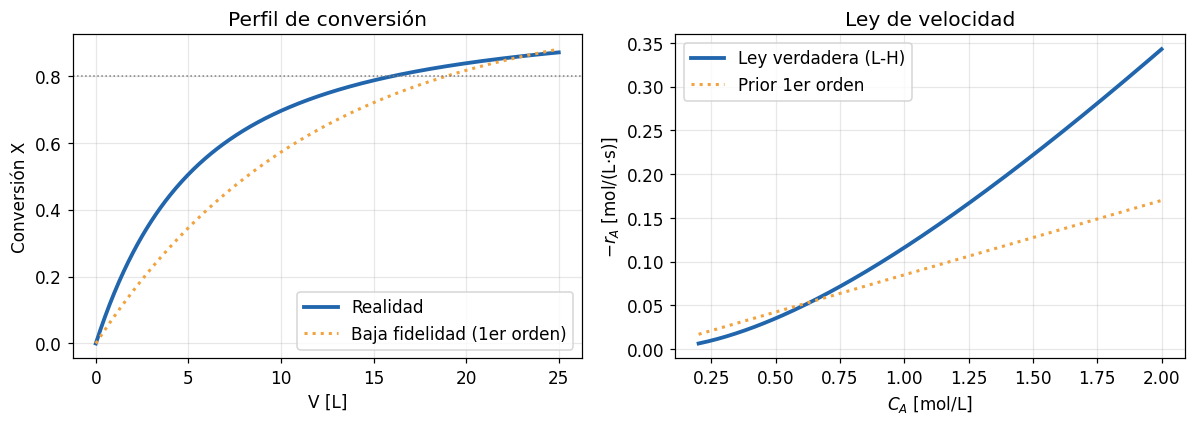

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(V_DENSE, X_TRUE_DENSE, color=C_TRUE, lw=2.5, label="Realidad")
a1.plot(V_DENSE, X_LF_DENSE, color=C_LF, ls=":", lw=2, label="Baja fidelidad (1er orden)")
a1.axhline(X_TARGET, color="gray", ls=":", lw=1)
a1.set(xlabel="V [L]", ylabel="Conversión X", title="Perfil de conversión"); a1.legend(); a1.grid(alpha=.3)
CA = np.linspace(0.2, C_A0, 200)
a2.plot(CA, rate_true(CA), color=C_TRUE, lw=2.5, label="Ley verdadera (L-H)")
a2.plot(CA, rate_lf(CA), color=C_LF, ls=":", lw=2, label="Prior 1er orden")
a2.set(xlabel="$C_A$ [mol/L]", ylabel=r"$-r_A$ [mol/(L·s)]", title="Ley de velocidad"); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Datos multi-fidelidad

| Fuente | Qué es | Costo | Cantidad | Sesgo |
|---|---|---|---|---|
| **Baja fidelidad** | modelo 1er orden | casi gratis | mucha | sí (~18%) |
| **Alta fidelidad** | experimentos reales + ruido ~3% | caro | poca | no |

La estrategia: usar el modelo barato como punto de partida y **corregirlo** con unos
pocos experimentos caros.

In [4]:
HF_SIGMA = 0.03   # ruido de medición (~3%)

def generar_experimentos(n, seed, V_lo=1.5, V_hi=22.0):
    "n experimentos de alta fidelidad repartidos en [V_lo, V_hi], con ruido nuevo."
    rng = np.random.default_rng(seed)
    V = np.linspace(V_lo, V_hi, n)
    Xg = integrate_pfr(rate_true, np.concatenate([[0.0], V]))[1:]
    X = np.clip(Xg + rng.normal(0, HF_SIGMA, size=Xg.shape), 0, 0.999)
    return V, X

Vh, Xh = generar_experimentos(6, seed=0)
print("Ejemplo de 6 experimentos de alta fidelidad:")
for v, x in zip(Vh, Xh):
    print(f"  V = {v:5.1f} L   ->   X = {x:.3f}   (C_A = {C_A0*(1-x):.2f} mol/L)")

Ejemplo de 6 experimentos de alta fidelidad:
  V =   1.5 L   ->   X = 0.219   (C_A = 1.56 mol/L)
  V =   5.6 L   ->   X = 0.534   (C_A = 0.93 mol/L)
  V =   9.7 L   ->   X = 0.707   (C_A = 0.59 mol/L)
  V =  13.8 L   ->   X = 0.773   (C_A = 0.45 mol/L)
  V =  17.9 L   ->   X = 0.804   (C_A = 0.39 mol/L)
  V =  22.0 L   ->   X = 0.864   (C_A = 0.27 mol/L)


## 3A. Modelo físico-informado = **red neuronal dentro de la EDO** (UDE)

Aquí está el *machine learning*. La incógnita —la ley de velocidad— la reemplazamos
por una **red neuronal** $NN_\theta(C_A)$ (un MLP de 1 capa oculta), escrita de forma
**multiplicativa** sobre el prior barato:

$$-r_A(C_A) = r_{LF}(C_A)\cdot \exp\big(NN_\theta(C_A)\big)$$

- Si la red vale 0 → recuperamos exactamente el prior de 1er orden (**ancla
  multi-fidelidad**).
- El $\exp(\cdot)$ garantiza velocidad **siempre positiva** → la EDO nunca da
  perfiles absurdos.

**Entrenamiento physics-informed:** metemos la red **dentro** del balance molar,
integramos el PFR y ajustamos los pesos $\theta$ minimizando

$$\min_\theta \sum_i \Big[\tfrac{X_{pred}(V_i;\theta)-X_i}{\sigma}\Big]^2
  + \lambda^2\,\lVert \theta \rVert^2$$

El segundo término (regularización L2) mantiene la red pequeña → con pocos datos se
queda cerca del prior barato; los experimentos caros la mueven lo necesario. La red
es pequeña (pocas neuronas) **a propósito**: con 4–8 datos, más capacidad = más
sobreajuste (justo el problema que sufre la caja-negra).

In [5]:
H_NN = 3                    # neuronas ocultas (red pequeña: hay pocos datos)
CA_MU, CA_SD = 1.0, 0.55    # escalado de la entrada C_A

def _nn_forward(theta, C_A):
    "MLP 1 capa oculta (tanh). theta = [W1(H), b1(H), W2(H), b2(1)] -> 3H+1 pesos."
    W1 = theta[:H_NN]; b1 = theta[H_NN:2*H_NN]; W2 = theta[2*H_NN:3*H_NN]; b2 = theta[3*H_NN]
    xs = (np.atleast_1d(C_A) - CA_MU) / CA_SD
    h = np.tanh(xs[:, None]*W1[None, :] + b1[None, :])
    return h @ W2 + b2

def rate_pinn(theta, C_A):
    "Ley de velocidad aprendida por la red: prior * exp(red). Siempre positiva."
    return rate_lf(np.atleast_1d(C_A)) * np.exp(_nn_forward(theta, C_A))

def fit_fisico_informado(V_hf, X_hf, lam=0.4, seed=0):
    "Entrena la red DENTRO del balance molar con pocos experimentos caros."
    rng = np.random.default_rng(seed)
    theta0 = rng.normal(0, 0.05, size=3*H_NN + 1)   # pesos ~0 => arranca en el prior
    V_int = np.linspace(0.0, V_MAX, 70)
    def residuals(theta):
        Xg = integrate_pfr(lambda CA: rate_pinn(theta, CA), V_int)
        Xp = np.interp(V_hf, V_int, Xg)
        return np.concatenate([(Xp - X_hf)/HF_SIGMA, lam*theta])
    return least_squares(residuals, theta0, method="trf", max_nfev=150).x

def predict_fisico_informado(theta, V_grid):
    V_int = np.linspace(0.0, V_MAX, 160)
    return np.interp(V_grid, V_int, integrate_pfr(lambda CA: rate_pinn(theta, CA), V_int))

### El ciclo de entrenamiento (cómo aprende la red)

Fíjate en el flujo: la red recibe la **concentración** `C_A`, produce la **velocidad**,
esta entra al **balance molar** (física fija), se **integra** para dar el perfil de
conversión, y solo al final se compara con las **pocas conversiones medidas**. El error
se propaga hacia atrás para **ajustar los pesos** θ. La red **nunca ve la velocidad
"real"**: aprende de forma indirecta, a través de la física. Por eso el input es `C_A`,
pero la desviación se mide sobre `X` (lo único que se puede medir).

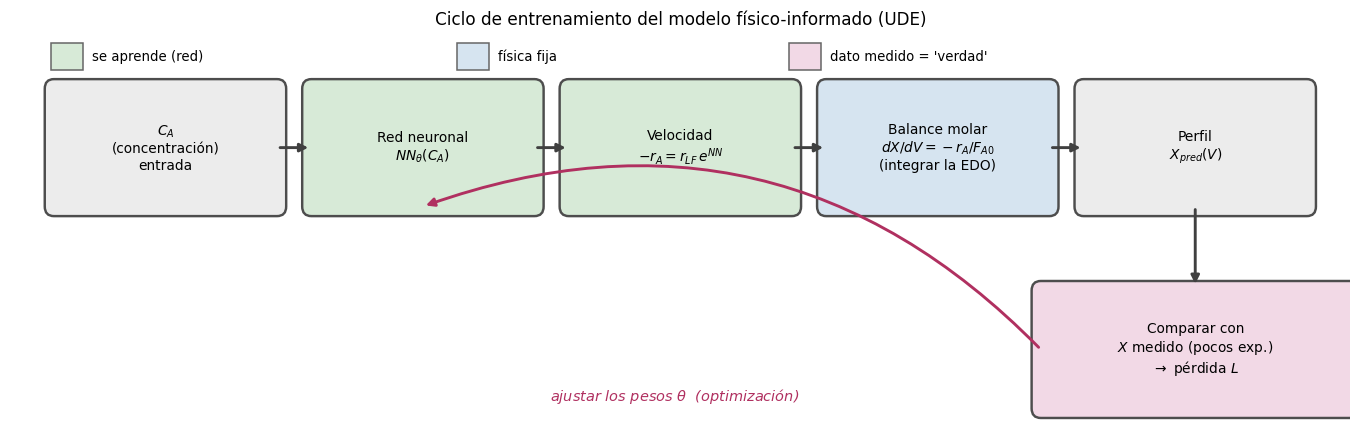

In [6]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12.5, 4.2)); ax.axis("off")
ax.set_xlim(-0.2, 11.5); ax.set_ylim(0, 3.35)

def box(x, y, text, fc, w=1.95, h=0.98):
    ax.add_patch(mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                 boxstyle="round,pad=0.08", fc=fc, ec="0.3", lw=1.6))
    ax.text(x, y, text, ha="center", va="center", fontsize=9)

def arrow(x1, y1, x2, y2, rad=0.0, color="0.25"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.9,
                                connectionstyle=f"arc3,rad={rad}"))

APREN, FISICA, DATO, NEUTRO = "#d7ead7", "#d6e4f0", "#f2d9e6", "#ececec"
yb, w = 2.4, 1.95
cx = [1.15, 3.4, 5.65, 7.9, 10.15]
box(cx[0], yb, "$C_A$\n(concentración)\nentrada", NEUTRO)
box(cx[1], yb, "Red neuronal\n$NN_\\theta(C_A)$", APREN)
box(cx[2], yb, "Velocidad\n$-r_A=r_{LF}\\,e^{NN}$", APREN)
box(cx[3], yb, "Balance molar\n$dX/dV=-r_A/F_{A0}$\n(integrar la EDO)", FISICA)
box(cx[4], yb, "Perfil\n$X_{pred}(V)$", NEUTRO)
for i in range(4):
    arrow(cx[i]+w/2, yb, cx[i+1]-w/2, yb)

# comparar con lo medido (debajo del perfil)
box(cx[4], 0.72, "Comparar con\n$X$ medido (pocos exp.)\n$\\rightarrow$ pérdida $L$", DATO, w=2.7)
arrow(cx[4], yb-0.49, cx[4], 0.72+0.52)
# retroalimentación: ajustar pesos (de la pérdida a la red)
arrow(cx[4]-1.35, 0.72, cx[1], yb-0.49, rad=0.32, color="#b03060")
ax.text(5.6, 0.30, "ajustar los pesos $\\theta$  (optimización)",
        ha="center", fontsize=9.5, color="#b03060", style="italic")

# leyenda de colores
for x, c, t in [(0.15, APREN, "se aprende (red)"), (3.7, FISICA, "física fija"),
                (6.6, DATO, "dato medido = 'verdad'")]:
    ax.add_patch(mpatches.Rectangle((x, 3.05), 0.28, 0.22, fc=c, ec="0.4"))
    ax.text(x+0.36, 3.16, t, va="center", fontsize=8.7)

plt.title("Ciclo de entrenamiento del modelo físico-informado (UDE)", fontsize=11)
plt.tight_layout(); plt.show()

## 3B. Modelo caja-negra

Una red neuronal (MLP) aprende directamente el mapa `V → X`. No sabe nada del
balance molar ni de que existe una ley de velocidad.

In [7]:
def fit_caja_negra(V_hf, X_hf, seed=0):
    sc = StandardScaler().fit(V_hf.reshape(-1, 1))
    mlp = MLPRegressor(hidden_layer_sizes=(32, 32), activation="tanh",
                       solver="lbfgs", alpha=1e-3, max_iter=4000, random_state=seed)
    mlp.fit(sc.transform(V_hf.reshape(-1, 1)), X_hf)
    return sc, mlp

def predict_caja_negra(model, V_grid):
    sc, mlp = model
    return np.clip(mlp.predict(sc.transform(np.asarray(V_grid).reshape(-1, 1))), 0, 0.999)

## 4. Comparación con POCOS datos (interpolación)

Con solo 6 experimentos repartidos en el reactor: el físico-informado sigue la
verdad; la caja-negra serpentea entre los puntos y cruza `X=0.8` en el `V` equivocado.

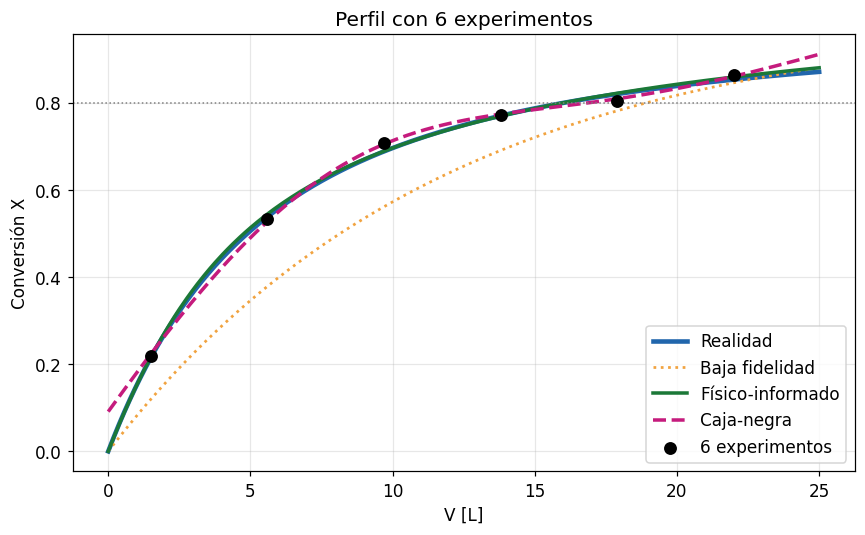

V* real = 16.0 L
V* físico-informado = 16.0 L
V* caja-negra       = 16.9 L


In [8]:
n = 6
Vh, Xh = generar_experimentos(n, seed=0)
p = fit_fisico_informado(Vh, Xh)
m = fit_caja_negra(Vh, Xh)
Xpi = predict_fisico_informado(p, V_DENSE)
Xbb = predict_caja_negra(m, V_DENSE)

plt.figure(figsize=(8, 5))
plt.plot(V_DENSE, X_TRUE_DENSE, color=C_TRUE, lw=3, label="Realidad")
plt.plot(V_DENSE, X_LF_DENSE, color=C_LF, ls=":", lw=1.8, label="Baja fidelidad")
plt.plot(V_DENSE, Xpi, color=C_PI, lw=2.3, label="Físico-informado")
plt.plot(V_DENSE, Xbb, color=C_BB, ls="--", lw=2.3, label="Caja-negra")
plt.scatter(Vh, Xh, color="k", s=55, zorder=5, label=f"{n} experimentos")
plt.axhline(X_TARGET, color="gray", ls=":", lw=1)
plt.xlabel("V [L]"); plt.ylabel("Conversión X"); plt.legend(loc="lower right"); plt.grid(alpha=.3)
plt.title(f"Perfil con {n} experimentos"); plt.tight_layout(); plt.show()

print(f"V* real = {V_STAR_TRUE:.1f} L")
print(f"V* físico-informado = {volume_for_conversion(V_DENSE, Xpi, X_TARGET):.1f} L")
print(f"V* caja-negra       = {volume_for_conversion(V_DENSE, Xbb, X_TARGET):.1f} L")

## 5. Lo que la física regala: recuperar la ley de velocidad

El físico-informado no solo predice `X(V)`: **reconstruye la ley de velocidad
desconocida** $-r_A(C_A)$ a partir de unos pocos puntos. La caja-negra no tiene
ningún concepto de ley de velocidad.

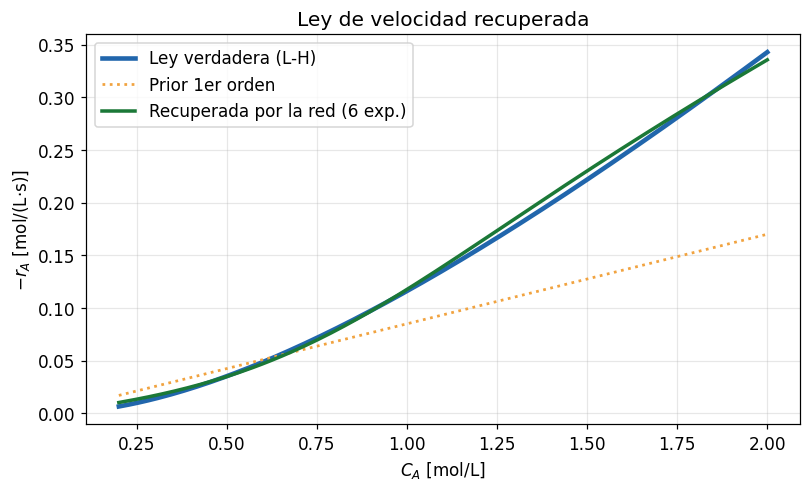

In [9]:
CA = np.linspace(0.2, C_A0, 200)
plt.figure(figsize=(7.5, 4.6))
plt.plot(CA, rate_true(CA), color=C_TRUE, lw=3, label="Ley verdadera (L-H)")
plt.plot(CA, rate_lf(CA), color=C_LF, ls=":", lw=1.8, label="Prior 1er orden")
plt.plot(CA, rate_pinn(p, CA), color=C_PI, lw=2.3, label=f"Recuperada por la red ({n} exp.)")
plt.xlabel("$C_A$ [mol/L]"); plt.ylabel(r"$-r_A$ [mol/(L·s)]")
plt.legend(); plt.grid(alpha=.3); plt.title("Ley de velocidad recuperada"); plt.tight_layout(); plt.show()

## 5b. De la corazonada barata a la ley aprendida (la lógica multi-fidelidad)

Aquí se ve el mecanismo completo. La red **arranca en el prior barato** (cinética de
1er orden, cuando todos sus pesos valen 0) y, tras ver **solo unos pocos experimentos
caros**, corrige la ley de velocidad hacia la verdad.

- **Panel izquierdo:** la ley $-r_A(C_A)$. Cómo pasa del prior (punteado) a la
  aprendida (verde), acercándose a la verdadera (azul).
- **Panel derecho:** el perfil $X(V)$ que produce cada ley. El prior sub-estima;
  la aprendida pasa por los pocos puntos caros y reproduce la realidad.

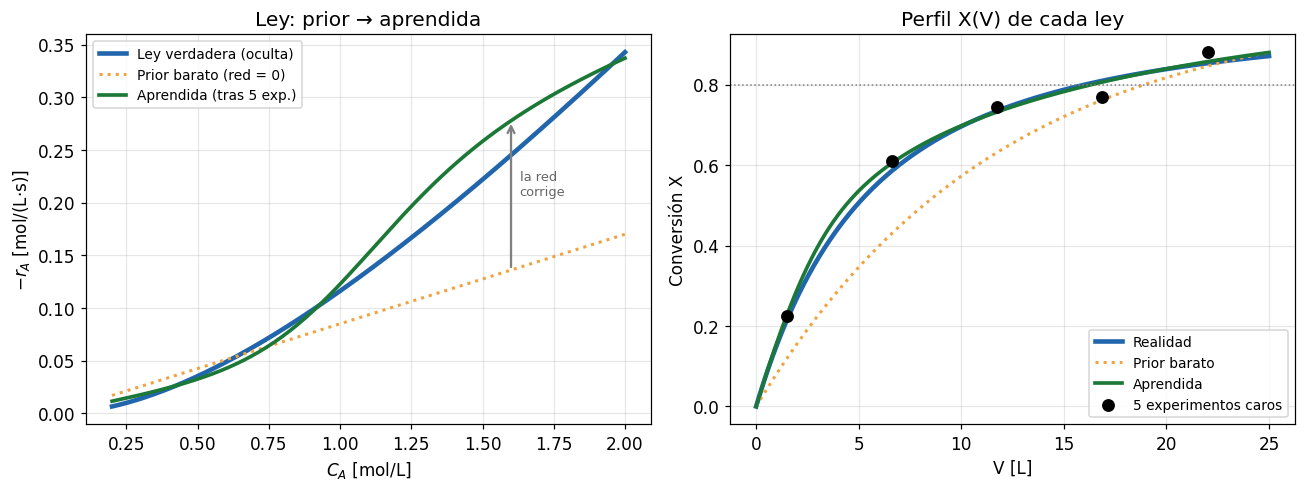

En C_A = 1.5 mol/L la red aprendió un multiplicador exp(NN) = 2.03  (prior = 1.00)
=> corrige la velocidad del prior barato en ~103% para acercarse a la realidad.


In [10]:
n_demo = 5
Vh_d, Xh_d = generar_experimentos(n_demo, seed=1)          # pocos experimentos caros
theta_prior = np.zeros(3*H_NN + 1)                         # red = 0  ->  ley = prior barato
theta_learn = fit_fisico_informado(Vh_d, Xh_d, seed=1)     # red entrenada con esos puntos

CA = np.linspace(0.2, C_A0, 200)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))

# --- Panel izquierdo: la ley de velocidad ---
a1.plot(CA, rate_true(CA), color=C_TRUE, lw=3, label="Ley verdadera (oculta)")
a1.plot(CA, rate_pinn(theta_prior, CA), color=C_LF, ls=":", lw=2, label="Prior barato (red = 0)")
a1.plot(CA, rate_pinn(theta_learn, CA), color=C_PI, lw=2.4, label=f"Aprendida (tras {n_demo} exp.)")
a1.annotate("", xy=(1.6, rate_pinn(theta_learn,1.6)[0]), xytext=(1.6, rate_pinn(theta_prior,1.6)[0]),
            arrowprops=dict(arrowstyle="->", color="0.5", lw=1.5))
a1.text(1.63, 0.5*(rate_pinn(theta_learn,1.6)[0]+rate_pinn(theta_prior,1.6)[0]),
        "la red\ncorrige", fontsize=8.5, color="0.4")
a1.set(xlabel="$C_A$ [mol/L]", ylabel=r"$-r_A$ [mol/(L·s)]", title="Ley: prior → aprendida")
a1.legend(fontsize=9); a1.grid(alpha=.3)

# --- Panel derecho: el perfil de conversión que produce cada ley ---
a2.plot(V_DENSE, X_TRUE_DENSE, color=C_TRUE, lw=3, label="Realidad")
a2.plot(V_DENSE, predict_fisico_informado(theta_prior, V_DENSE), color=C_LF, ls=":", lw=2, label="Prior barato")
a2.plot(V_DENSE, predict_fisico_informado(theta_learn, V_DENSE), color=C_PI, lw=2.4, label="Aprendida")
a2.scatter(Vh_d, Xh_d, color="k", s=55, zorder=5, label=f"{n_demo} experimentos caros")
a2.axhline(X_TARGET, color="gray", ls=":", lw=1)
a2.set(xlabel="V [L]", ylabel="Conversión X", title="Perfil X(V) de cada ley")
a2.legend(loc="lower right", fontsize=9); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

CA_ref = 1.5
mult = float(np.exp(_nn_forward(theta_learn, CA_ref))[0])
print(f"En C_A = {CA_ref} mol/L la red aprendió un multiplicador exp(NN) = {mult:.2f}  (prior = 1.00)")
print(f"=> corrige la velocidad del prior barato en ~{(mult-1)*100:.0f}% para acercarse a la realidad.")

## 6. Eficiencia de datos: ¿cuántos experimentos hacen falta?

Barremos el número de experimentos y promediamos sobre varias realizaciones de
ruido. El físico-informado tiene un **RMSE ~2× menor** y alcanza la tolerancia de
diseño (<5%) con **muchos menos experimentos**; la caja-negra sobreajusta el ruido
y su estimación de volumen es **errática**.

> Esta celda entrena decenas de modelos: tarda ~30–60 s.

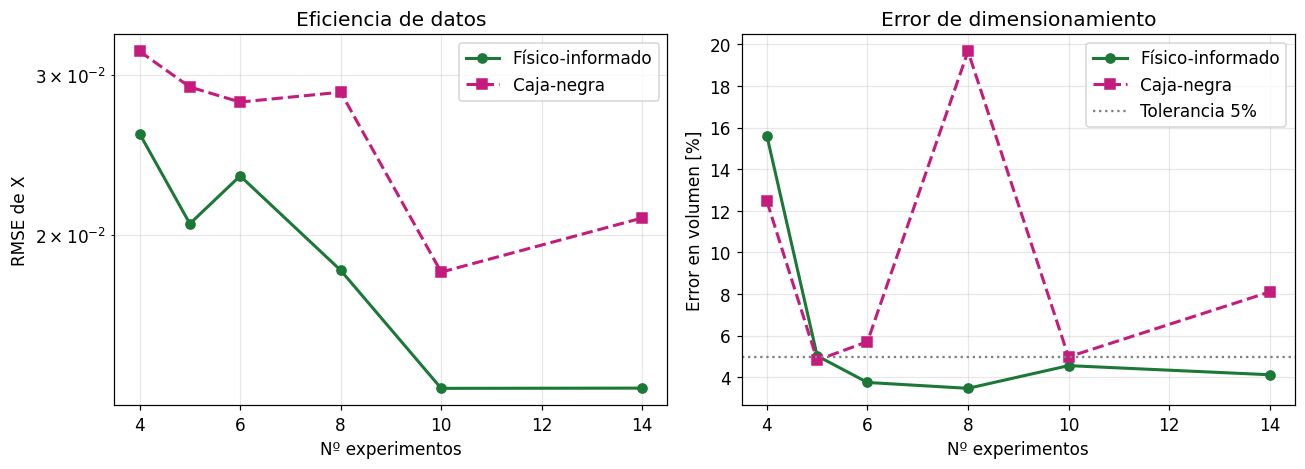

In [11]:
N_LIST = [4, 5, 6, 8, 10, 14]
N_TRIALS = 5
Vtest = np.linspace(0.5, V_MAX, 80); Xtest = np.interp(Vtest, V_DENSE, X_TRUE_DENSE)

rows = []
for nexp in N_LIST:
    for t in range(N_TRIALS):
        Vh, Xh = generar_experimentos(nexp, seed=1000*nexp + t)
        p = fit_fisico_informado(Vh, Xh, seed=t); Xpi = predict_fisico_informado(p, Vtest)
        m = fit_caja_negra(Vh, Xh, seed=t); Xbb = predict_caja_negra(m, Vtest)
        vpi = volume_for_conversion(Vtest, Xpi, X_TARGET)
        vbb = volume_for_conversion(Vtest, Xbb, X_TARGET)
        rows.append((nexp, rmse(Xpi, Xtest), rmse(Xbb, Xtest),
                     abs(vpi-V_STAR_TRUE)/V_STAR_TRUE*100 if not np.isnan(vpi) else np.nan,
                     abs(vbb-V_STAR_TRUE)/V_STAR_TRUE*100 if not np.isnan(vbb) else np.nan))
R = np.array(rows)
ns = np.array(N_LIST, float)
def mean_by_n(col):
    return np.array([np.nanmean(R[R[:,0]==k, col]) for k in N_LIST])
rmse_pi, rmse_bb = mean_by_n(1), mean_by_n(2)
vol_pi,  vol_bb  = mean_by_n(3), mean_by_n(4)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.plot(ns, rmse_pi, "o-", color=C_PI, lw=2, label="Físico-informado")
a1.plot(ns, rmse_bb, "s--", color=C_BB, lw=2, label="Caja-negra")
a1.set_yscale("log"); a1.set(xlabel="Nº experimentos", ylabel="RMSE de X", title="Eficiencia de datos")
a1.legend(); a1.grid(alpha=.3, which="both")
a2.plot(ns, vol_pi, "o-", color=C_PI, lw=2, label="Físico-informado")
a2.plot(ns, vol_bb, "s--", color=C_BB, lw=2, label="Caja-negra")
a2.axhline(5, color="gray", ls=":", label="Tolerancia 5%")
a2.set(xlabel="Nº experimentos", ylabel="Error en volumen [%]", title="Error de dimensionamiento")
a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. El caso más revelador: EXTRAPOLACIÓN

Situación real: hiciste experimentos solo en **reactores pequeños** (baja conversión,
`X ≲ 0.64`) porque son baratos y rápidos. ¿Puedes dimensionar el **reactor grande**
para `X=0.8`, que está **fuera** del rango de tus datos?

- **Físico-informado:** el balance molar le permite **extrapolar** con sentido
  físico → alcanza `X=0.8` cerca del volumen real.
- **Caja-negra:** fuera de sus datos, extrapola sin control. Aquí **sub-dimensiona**
  el reactor ~30% (y en otras realizaciones su curva ni siquiera llega a `X=0.8`).

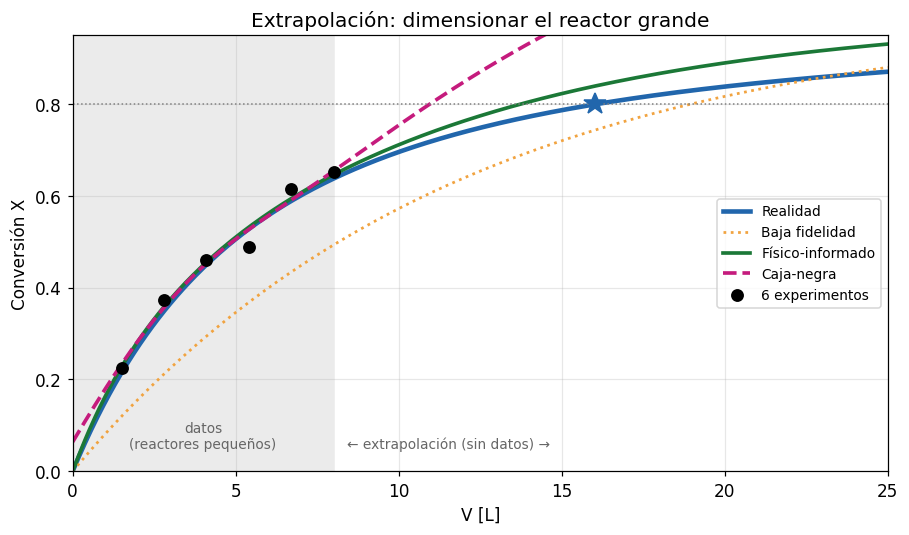

V* real              = 16.0 L
V* físico-informado  = 13.7 L   (error 14%)
V* caja-negra        = 10.9 L   (error 32%, sub-dimensiona)


In [12]:
n = 6; V_TRAIN = 8.0; seed = 1
Vh, Xh = generar_experimentos(n, seed=seed, V_lo=1.5, V_hi=V_TRAIN)  # datos solo en baja conversión
p = fit_fisico_informado(Vh, Xh, seed=seed)
m = fit_caja_negra(Vh, Xh, seed=seed)
Xpi = predict_fisico_informado(p, V_DENSE)
Xbb = predict_caja_negra(m, V_DENSE)
Vpi = volume_for_conversion(V_DENSE, Xpi, X_TARGET)
Vbb = volume_for_conversion(V_DENSE, Xbb, X_TARGET)

plt.figure(figsize=(8.4, 5))
plt.axvspan(0, V_TRAIN, color="0.92")
plt.text(V_TRAIN/2, 0.05, "datos\n(reactores pequeños)", ha="center", fontsize=9, color="0.4")
plt.text(V_TRAIN+0.4, 0.05, "← extrapolación (sin datos) →", fontsize=9, color="0.4")
plt.plot(V_DENSE, X_TRUE_DENSE, color=C_TRUE, lw=3, label="Realidad")
plt.plot(V_DENSE, X_LF_DENSE, color=C_LF, ls=":", lw=1.8, label="Baja fidelidad")
plt.plot(V_DENSE, Xpi, color=C_PI, lw=2.4, label="Físico-informado")
plt.plot(V_DENSE, Xbb, color=C_BB, ls="--", lw=2.4, label="Caja-negra")
plt.scatter(Vh, Xh, color="k", s=55, zorder=6, label=f"{n} experimentos")
plt.axhline(X_TARGET, color="gray", ls=":", lw=1)
plt.plot([V_STAR_TRUE], [X_TARGET], "*", color=C_TRUE, ms=15, zorder=7)
plt.xlim(0, V_MAX); plt.ylim(0, 0.95)
plt.xlabel("V [L]"); plt.ylabel("Conversión X"); plt.legend(loc="center right", fontsize=9)
plt.grid(alpha=.3); plt.title("Extrapolación: dimensionar el reactor grande"); plt.tight_layout(); plt.show()

print(f"V* real              = {V_STAR_TRUE:.1f} L")
print(f"V* físico-informado  = {Vpi:.1f} L   (error {abs(Vpi-V_STAR_TRUE)/V_STAR_TRUE*100:.0f}%)")
print(f"V* caja-negra        = " + ("NO ALCANZA X=0.8" if np.isnan(Vbb)
      else f"{Vbb:.1f} L   (error {abs(Vbb-V_STAR_TRUE)/V_STAR_TRUE*100:.0f}%, sub-dimensiona)"))

## Conclusiones

- **Atar el modelo a la física** (balance molar) reduce los grados de libertad:
  en vez de aprender la curva `X(V)` completa, solo aprendemos la ley de velocidad.
  Por eso necesita **muchos menos datos**.
- La **multi-fidelidad** aporta el modelo barato como *prior*; los experimentos
  caros solo lo corrigen → menos costo experimental y computacional.
- El físico-informado además **recupera la ley de velocidad** (interpretable) y
  **extrapola** con sentido físico. La caja-negra hace ninguna de las dos.

**Honestidad intelectual:** la caja-negra interpola una curva suave razonablemente;
su debilidad es el ruido con pocos datos, la falta de estructura y la extrapolación.
Y el físico-informado supone que el balance molar es correcto: si la física asumida
está mal (no isotérmico, mezclado no ideal), ese sesgo se traslada.